# TALLER 2: ENTRENAMIENTO DE MODELOS DE MACHINE LEARNING

Ciencia de Datos Aplicada 25-2

Miguel Felipe Benavides Lara
Santiago Palacios Loaiza


## Punto 0: Importación de librerías


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Punto 1: Contextualización de los datos


### Entendimiento del dataset

El dataset presentado es una recopilación de datos de propiedades que es una muerstra de información de apartamentos en el meracdo de los últimos dos meses.

In [80]:
df = pd.read_csv('./apartamentos.csv')

Las dimensiones del dataset se presentan a continuación

In [81]:
print('El número de filas del dataset original corresponden a: ', df.shape[0],'\n','mientras que el número de columnas es: ',df.shape[1])

El número de filas del dataset original corresponden a:  43013 
 mientras que el número de columnas es:  46


De manera preliminar,se eliminan registros con valores de venta menores a 100.000.000 COP Y mayores a 30.000.000.000 COP ya que, partiendo del entendimiento del negocio y realizando un estudio de mercado sobre inmuebles en Bogotá, estos se muy probablemente se traten de datos erróneos.

In [82]:
print(df.isnull().sum())
df = df[(df['precio_venta']>100000000) & (df['precio_venta']<30000000000)]

_id                            0
codigo                         0
tipo_propiedad                 0
tipo_operacion                 0
precio_venta               15429
area                           0
habitaciones                   1
banos                          1
administracion              7925
parqueaderos                   1
sector                      1641
estrato                        1
antiguedad                    10
latitud                        0
longitud                       0
direccion                  42219
descripcion                    0
website                        2
last_view                      2
datetime                       2
url                        42219
timeline                   13586
estado                       796
compañia                    4530
precio_arriendo            27184
jacuzzi                        2
piso                       43013
closets                    43013
chimenea                       2
permite_mascotas               2
gimnasio  

Hay columnas irrelevantes para el entrenamiento del modelo que se va a entrenar. Por ejemplo,  precio de arriendo, que no se utilizará ya que para el modelo se utilizarán precios de venta, y las descripciones, que no se encuentran utilizables para  los algoritmos que se emplearán. Las direcciones se referenciarán a través de barrios y sectores, por lo que de igual manera son descartables. En el análisis de variables nulas, se encontró que pisos y closets no tienen valor, por lo que también se elimina. Para este modelo, no se utilizará la compañía que vende el inmueble. El resto de variables, son intrínsecas del proceso de web scraping y por ende se descarta. También se descartan la columna de estacion tm cercana y parque cercano, se considera que la distancia y que el booleano de si está cerca o no es suficiente información para el modelo.

Debido al objeto del modelo, se van a tener solo propiedades de tipo apartamento y con tipo_operacion de venta o venta y arriendo

In [83]:
col_drop = ['_id','codigo','direccion','url','last_view','website','descripcion','datetime','timeline','piso','closets','precio_arriendo','compañia','estacion_tm_cercana','parque_cercano']
print(col_drop)
df_Venta = df.drop(col_drop, axis=1)
df_Venta = df_Venta[(df_Venta['tipo_propiedad'] == "APARTAMENTO") & (df_Venta['tipo_operacion'] != 'ARRIENDO')]

['_id', 'codigo', 'direccion', 'url', 'last_view', 'website', 'descripcion', 'datetime', 'timeline', 'piso', 'closets', 'precio_arriendo', 'compañia', 'estacion_tm_cercana', 'parque_cercano']


Luego se estudian las valores numéricas continuas como precio de venta, área, administración, distancia a estación de tm y distancia a parque. Se encuentra una gran distribución de datos a la izquieda de las gráficas con largas pero poco representativas colas de datos a la derecha. Unos cuantos precios de venta, áreas y administraciones muy elevadas.

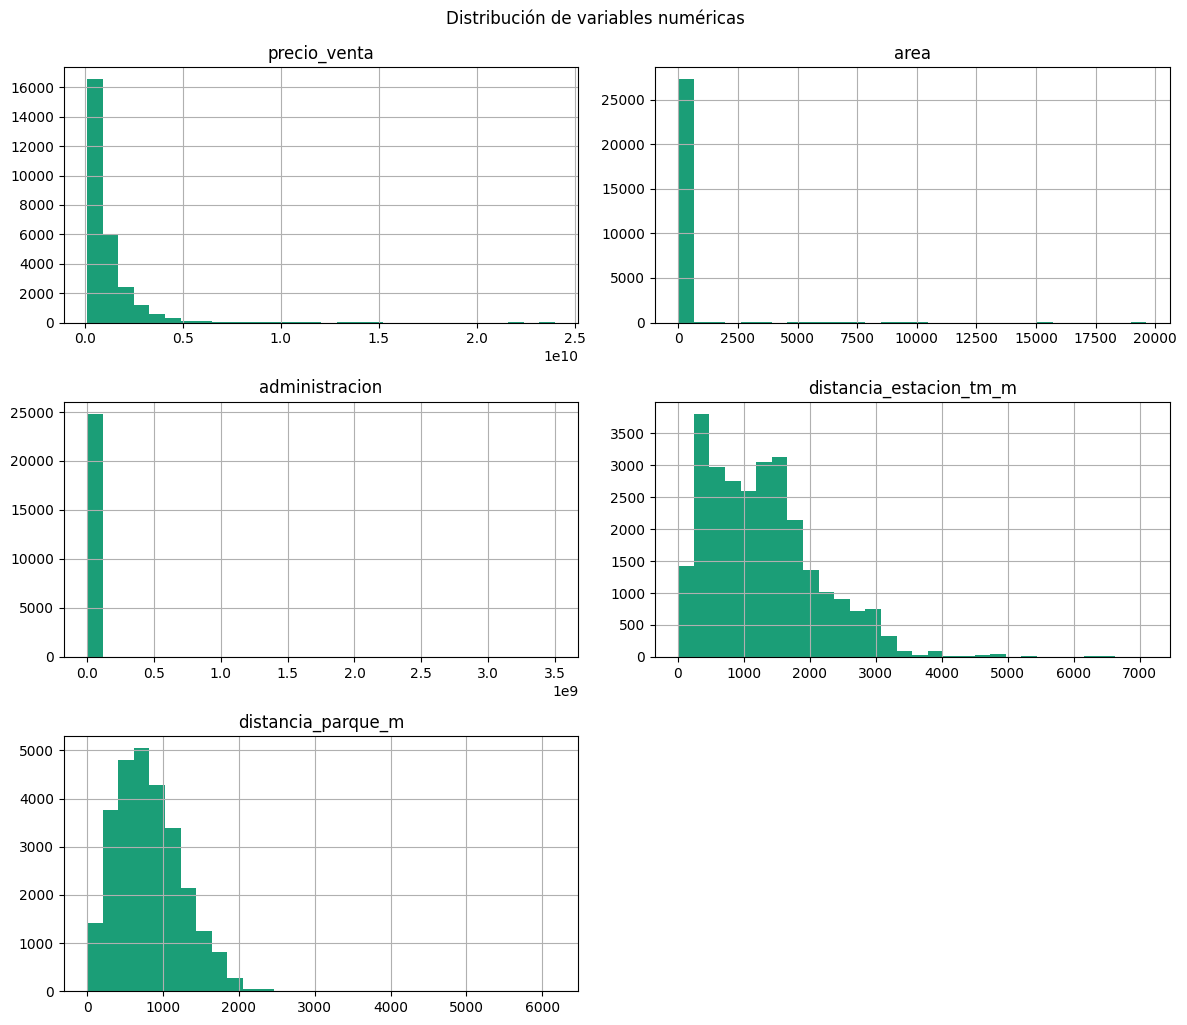

In [84]:
var_num_continuas = ['precio_venta','area','administracion','distancia_estacion_tm_m','distancia_parque_m']
df_Venta[var_num_continuas].hist(bins=30, figsize=(12,10), color='#1b9e77')
plt.tight_layout()
plt.suptitle('Distribución de variables numéricas', y=1.02)
plt.show()

Analizando el dataset, se encontró que hay una serie de columnas que corresponden a características extras no funcionales de los apartamentos pertenecientes a la muestra. Para determinar cuáles de estos pueden ser relevantes para el estudio del modelo, se estudió la participación de sus valores en el dataset presentado.

In [85]:
extras = ['jacuzzi','chimenea','permite_mascotas','gimnasio','ascensor','conjunto_cerrado','piscina','salon_comunal','terraza','vigilancia']
for e in extras:
    print(df_Venta[e].value_counts(normalize=True).round(2))
    

jacuzzi
0.0    0.95
1.0    0.05
Name: proportion, dtype: float64
chimenea
0.0    1.0
Name: proportion, dtype: float64
permite_mascotas
0.0    1.0
Name: proportion, dtype: float64
gimnasio
0.0    0.68
1.0    0.32
Name: proportion, dtype: float64
ascensor
1.0    0.65
0.0    0.35
Name: proportion, dtype: float64
conjunto_cerrado
0.0    0.57
1.0    0.43
Name: proportion, dtype: float64
piscina
0.0    0.9
1.0    0.1
Name: proportion, dtype: float64
salon_comunal
0.0    1.0
Name: proportion, dtype: float64
terraza
0.0    1.0
1.0    0.0
Name: proportion, dtype: float64
vigilancia
1.0    0.6
0.0    0.4
Name: proportion, dtype: float64


Pasando a las variables numericas discretas, se grafican barras. En este caso, y estudiando el análisis previamente presentado, para jacuzzi, chimenea, permite_mascotas, gimnasio, conjunto_cerrado, piscina, salon_comunal y terraza se crea una variable llamada "beneficios" la cual es acumulativa según el número de beneficios, la ascensor y vigilancia se mantienen por separado por su importancia en el analisis porcentual.

Este variable de beneficios puede aportar informacion al modelo, sin aumentar demasiado la dimensionalidad. Se asume que todas estas variables tienen una relacion equipable entre si


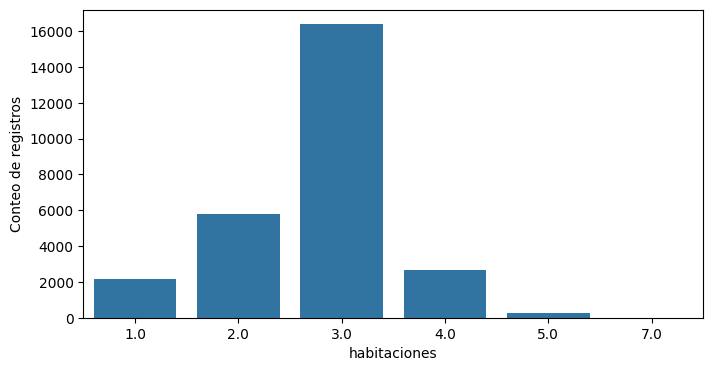

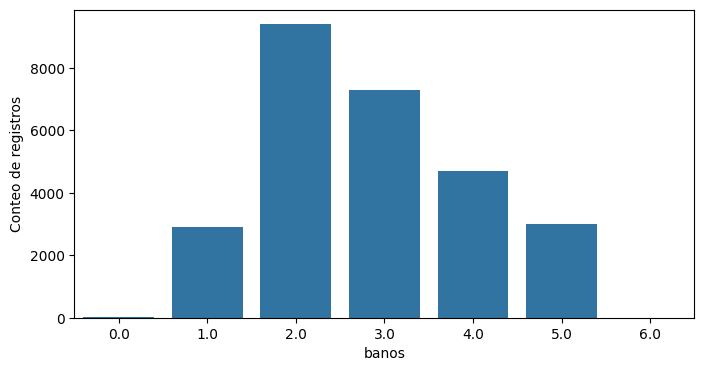

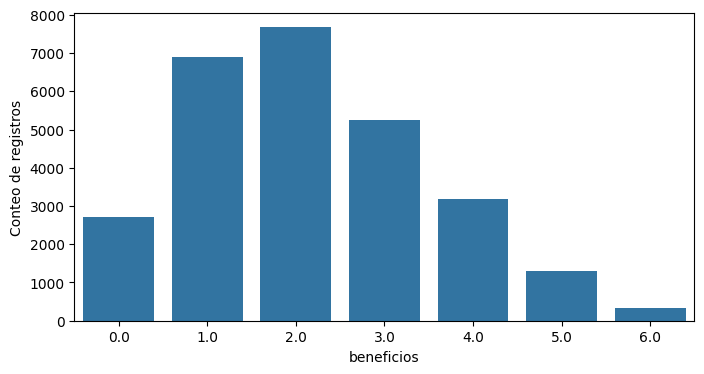

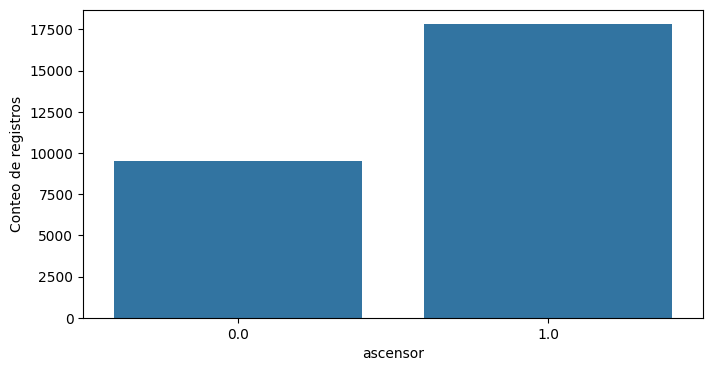

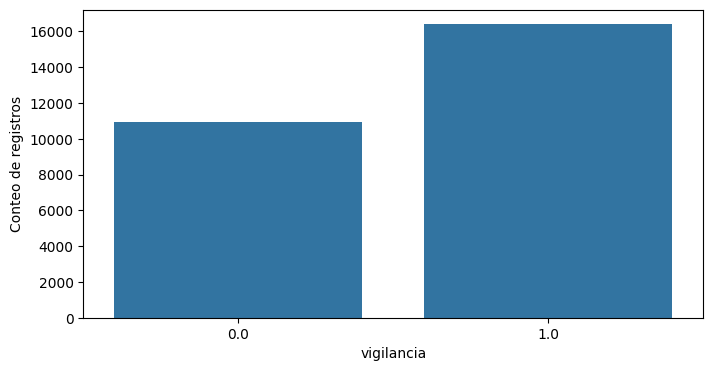

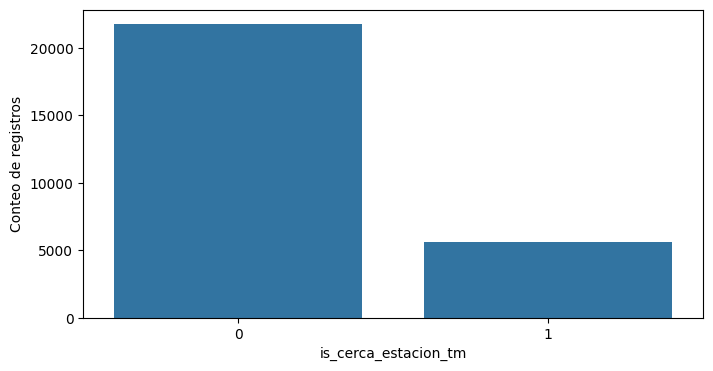

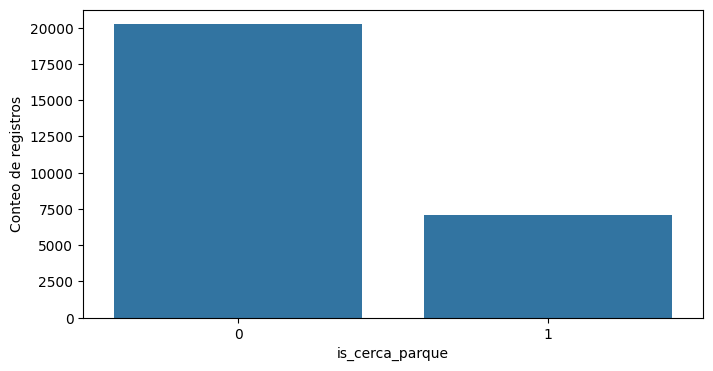

In [86]:
df_Venta['beneficios'] = 0
for e in extras:
    df_Venta['beneficios'] +=df_Venta[e]
        
val_num_disc = ['habitaciones','banos','beneficios','ascensor','vigilancia','is_cerca_estacion_tm','is_cerca_parque']
for col in val_num_disc:
    plt.figure(figsize=(8,4))
    plt.ylabel('Conteo de registros')
    sns.countplot(x=col, data=df_Venta,)
    plt.show()

Finalmente, se van a utilizar como variables categóricas el estrato, la antiguedad y el estado. No se presenta el sector y el barrio por la cantidad de posibles resultados

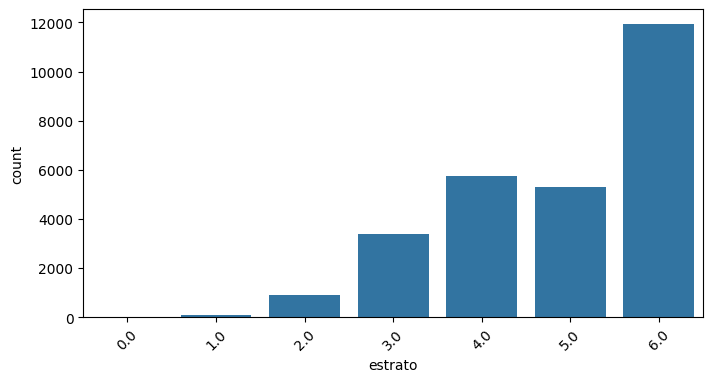

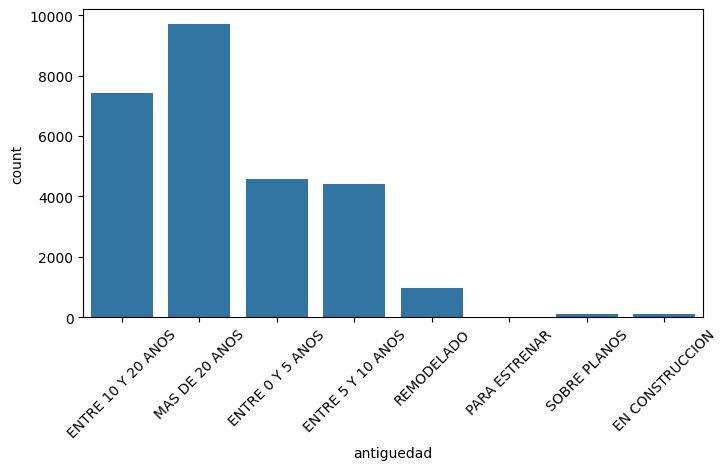

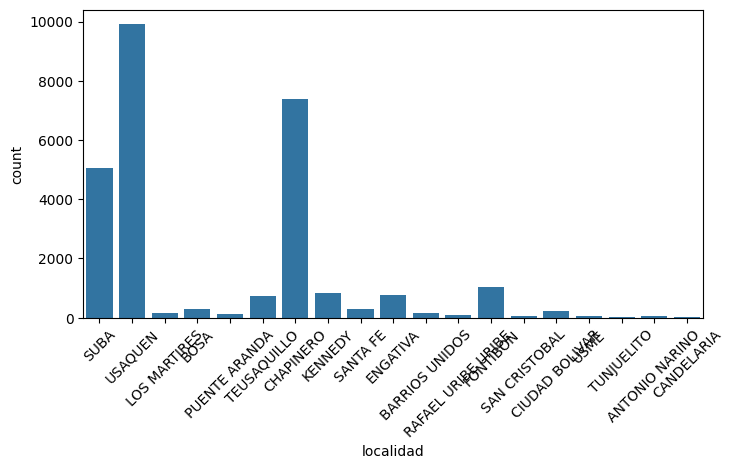

In [87]:
val_cat=['estrato','antiguedad','localidad']

for col in val_cat:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df_Venta)
    plt.xticks(rotation=45)
    plt.show()

Ahora se crean las variables dummy aplicando tecnicas de one hot encoding

In [88]:
df_Venta

df_Venta['antiguedad'] = df_Venta['antiguedad'].astype('category')
df_Venta['estrato'] = df_Venta['estrato'].astype('category')
df_Venta['localidad'] = df_Venta['localidad'].astype('category')
df_Venta = pd.get_dummies(df_Venta, columns=['estrato','antiguedad','localidad'], drop_first=True)


Se busca correlación entre las variables a través de la matriz de correlación presentada a continuación. No se evidencia una fuerte correlación en los datos presentados

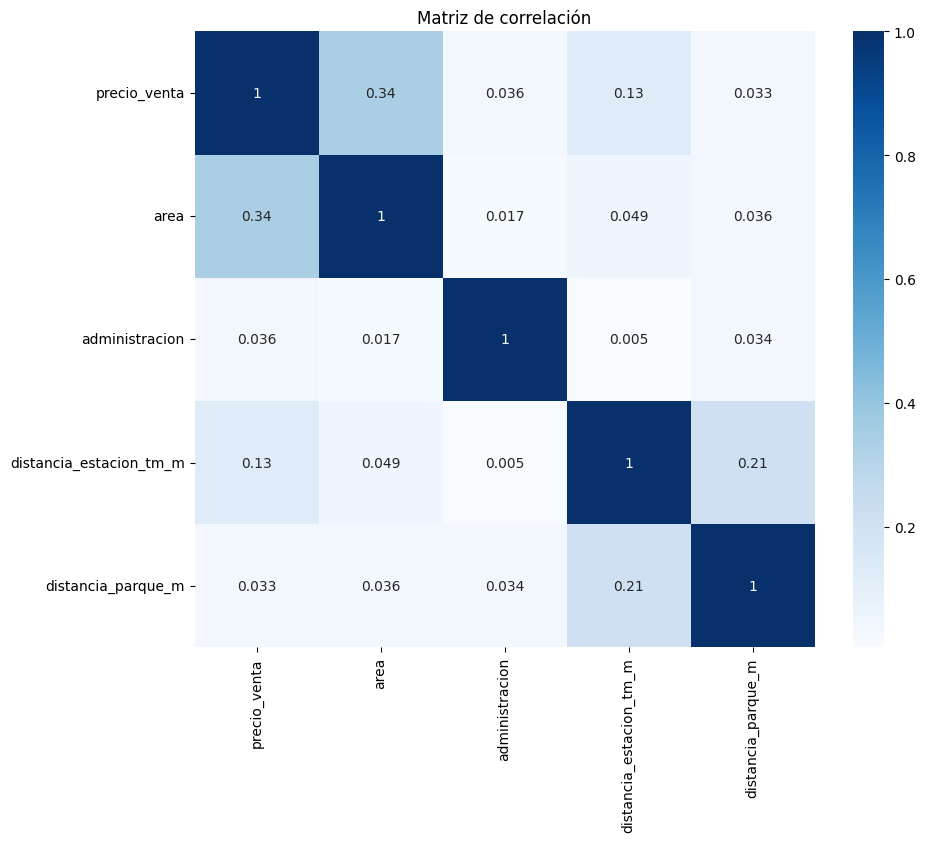

In [89]:
# Matriz de correlación de variables numéricas
import numpy as np
var_num_continuas = var_num_continuas
correlation = df_Venta[var_num_continuas].corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='Blues')
plt.title('Matriz de correlación')
plt.show()

Se estudia la distribución de la variable objetivo, en donde se encuentra una elevada presencia de outliers

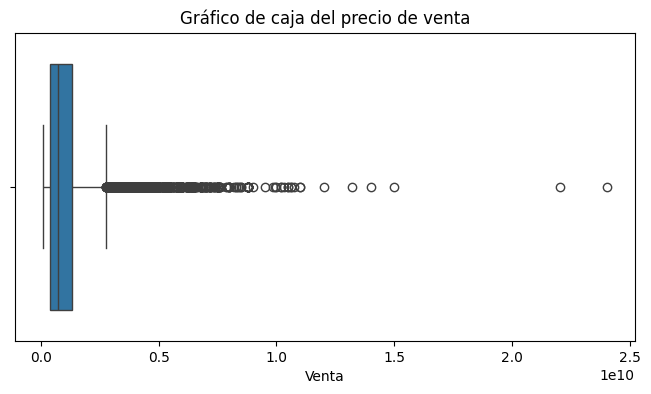

In [90]:
# Boxplot del precio de venta para identificar valores atípicos
plt.figure(figsize=(8,4))
sns.boxplot(data=df_Venta, x='precio_venta')
plt.title('Gráfico de caja del precio de venta')
plt.xlabel('Venta')
plt.show()

### Limpieza de los datos

Se va a iniciar la limpieza de los datos. Para esto, primero, se va a dividir el data set en training data, test data y validation data

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X=df_Venta.drop(columns='precio_venta')
y=df_Venta['precio_venta']

# Se separa la training y test data de la validation data, dejándole a validation 20%
X_train_temp, X_val, y_train_temp, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#se separa train y test data
X_train, X_test, y_train, y_test = train_test_split(
    X_train_temp, y_train_temp, test_size=0.25, random_state=42
)


#Para la limpieza de los datos, se crean los dataset de train, test y validation de acuerdo con las separaciones
train = X_train.copy()
train['precio_venta'] = y_train

test = X_test.copy()
test['precio_venta'] = y_test

val = X_val.copy()
val['precio_venta'] = y_val

Se hará limpieza de variables numéricas continuas primero, y luego se procederá a eliminar o imputar valores nulos, según corresponda.

Es importante recordar que se limpiarán los datos de training data y los mismos outliers numéricos identificados para training data se emplearan en test y validation data, partiendo del supuesto que la training data se comporta semejante a test y validation data. **Se reconoce que esto lleva a data leak, sin embargo, por la estructura de dataset y algunos datos, que aunque son de propiedades con características reales, son atípicos, y se encuentran presentes en el conjunto de datos de test y validation.** 

**Estas propiedades, al tener una participación tan baja con unas características tan diferentes en contraste, perjudica el rendimiento de los modelos con respecto a la gran mayoría de los datos. Esto se considera una mejora para futuras versiones del modelo**

In [14]:
#Mask permite no eliminar multiples registros a la vez
mask = pd.Series(True, index=train.index)
mask1 = pd.Series(True, index=test.index)
mask2 = pd.Series(True, index=val.index)
for col in var_num_continuas:
    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)
    iqr = q3-q1
    lowerbound = q1 - 3*iqr
    upperbound = q3 +3*iqr
    #Se aplican límites inferiores y superiores de training data para cada dataseto
    mask &= (train[col] >= lowerbound) & (train[col] <= upperbound)
    mask1 &= (test[col] >= lowerbound) & (test[col] <= upperbound)
    mask2 &= (val[col] >= lowerbound) & (val[col] <= upperbound)
train = train[mask]
test = test[mask1]
val = val[mask2]

Para valores nulos, para barrio, sector se inputa como valor desconocido. En cuanto a  estado, viendo que el resto de datos no nulos son "usado", se inputa "usado".

In [15]:
#Valores nulos

train['barrio'] = train['barrio'].fillna('DESCONOCIDO')
train['sector'] = train['sector'].fillna('DESCONOCIDO')
train['estado'] = train['estado'].fillna('USADO')
train = train.dropna(subset=['jacuzzi','chimenea','permite_mascotas','gimnasio','ascensor','conjunto_cerrado','piscina','salon_comunal'])
test['barrio'] = test['barrio'].fillna('DESCONOCIDO')
test['sector'] = test['sector'].fillna('DESCONOCIDO')
test['estado'] = test['estado'].fillna('USADO')
test = test.dropna(subset=['jacuzzi','chimenea','permite_mascotas','gimnasio','ascensor','conjunto_cerrado','piscina','salon_comunal'])


Quitando los valores nulos y filtrando las variables numéricas continuas según el criterio de iqr, se procede a checkear la distribución de interes de variables numéricas continuas y el box and whiskers de la variable objetivo. Se evidencia una menor concentración hacia la izquierda de los ejes de la gráfica. De igual manera, las colas extendidas hacia la derecha de las gráficas se reducen.

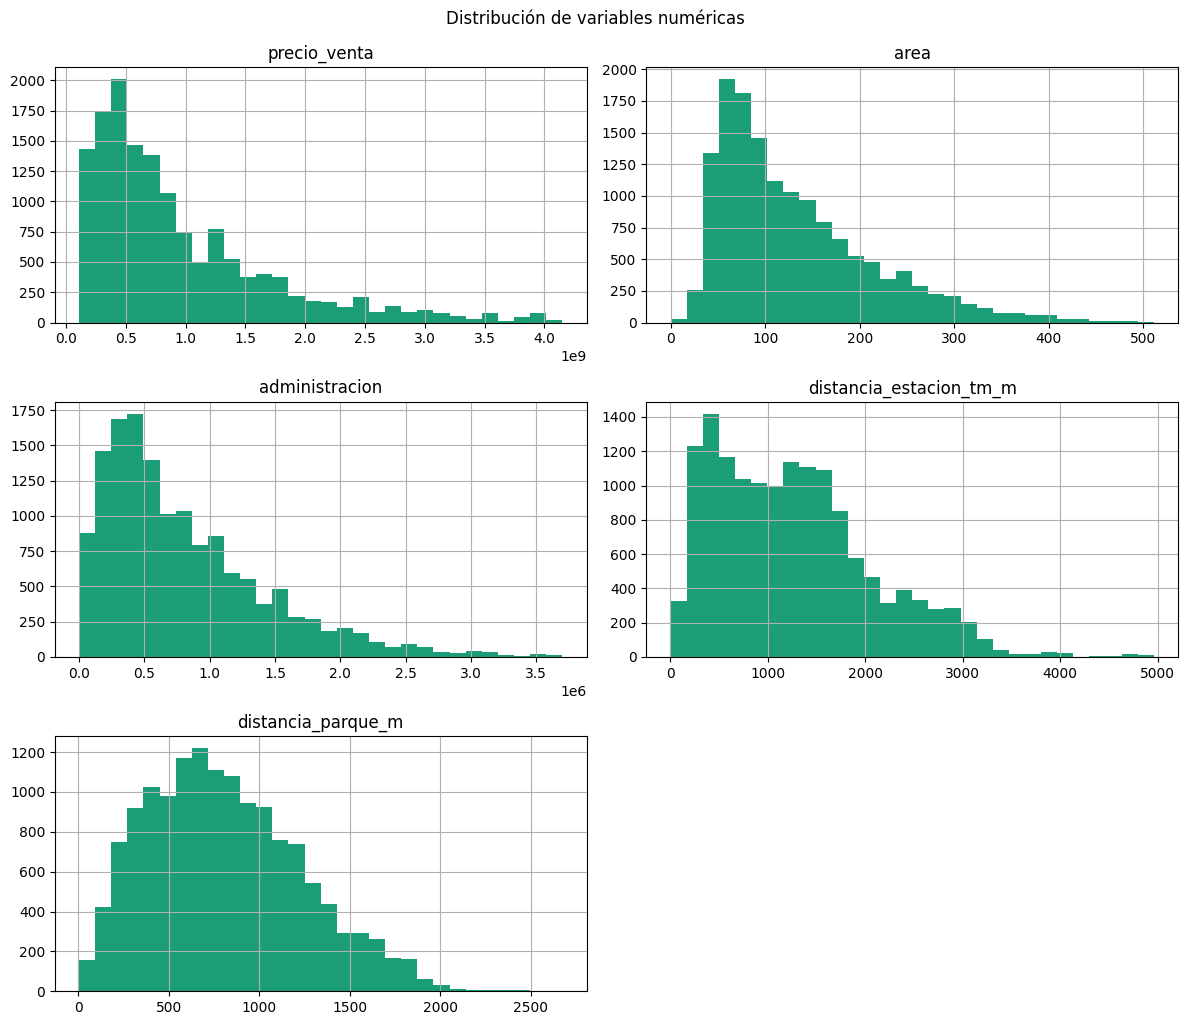

In [16]:
train[var_num_continuas].hist(bins=30, figsize=(12,10), color='#1b9e77')
plt.tight_layout()
plt.suptitle('Distribución de variables numéricas', y=1.02)
plt.show()

Realizando una nueva matriz de correlación con los datos filtrados, se identifican claras tendencias de correlación entre precios de venta, la administración y el área de los apartamentos. Esta son variables que se considerarán importantes en el entrenamiento de los modelos

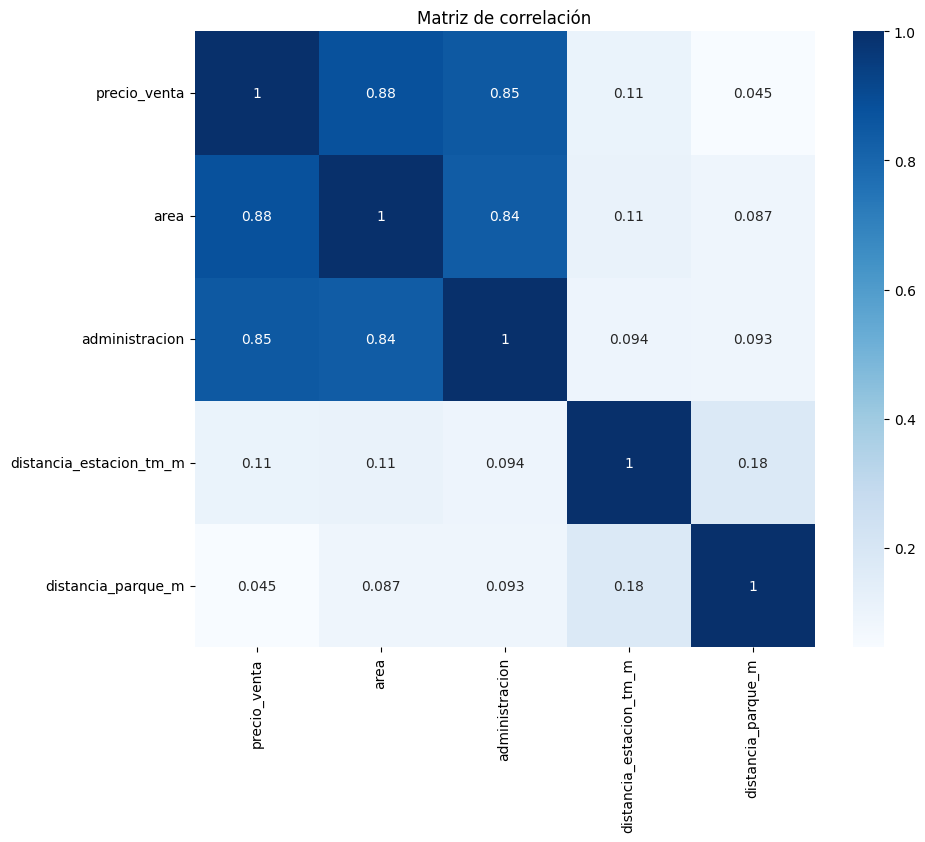

In [17]:
# Matriz de correlación de variables numéricas
import numpy as np
var_num_continuas = var_num_continuas
correlation = train[var_num_continuas].corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='Blues')
plt.title('Matriz de correlación')
plt.show()

De igual manera, analizando al distribución de la variable objetivo, se encuentra que se reduce el rango de datos atípicos.

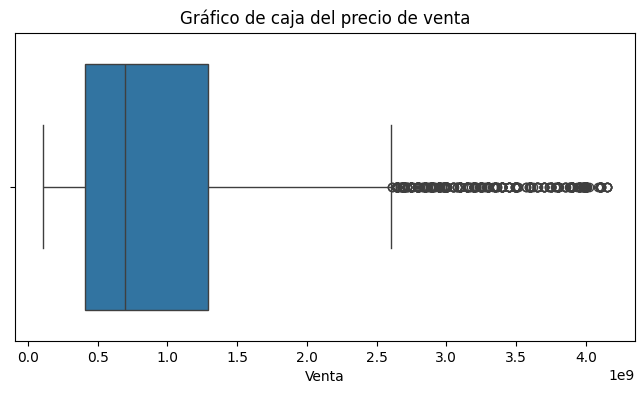

In [18]:
# Boxplot del precio de venta para identificar valores atípicos
plt.figure(figsize=(8,4))
sns.boxplot(x=train['precio_venta'])
plt.title('Gráfico de caja del precio de venta')
plt.xlabel('Venta')
plt.show()

### Variables a analizar y preparación de datos para los modelos

Primero se van a analizar las variables numericas continuas. 

En el caso del área y la administración, se identifica una tendencia lineal entre el precio de venta de los inmuebles. Mayor area y mayor valor de administracion estan relacionados con el mayor precio de venta 

En el caso de la cercanía a estaciones de TransMilenio y cercanía a parques, no se identifica claramente una tendencia clara en la relacion con la variable objetivo

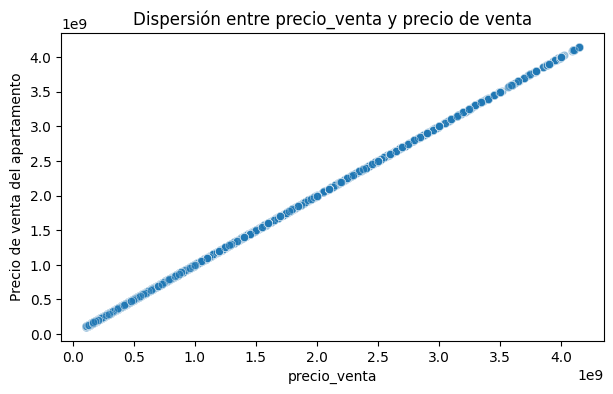

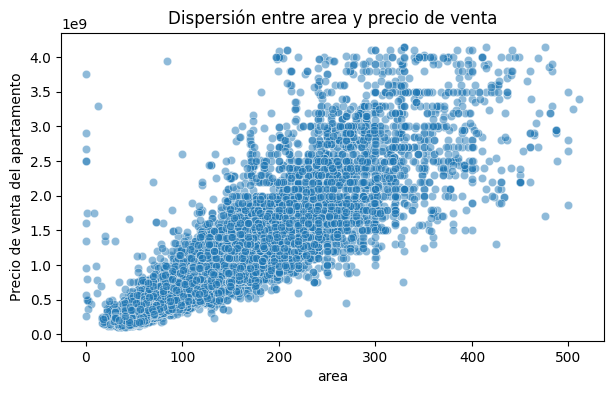

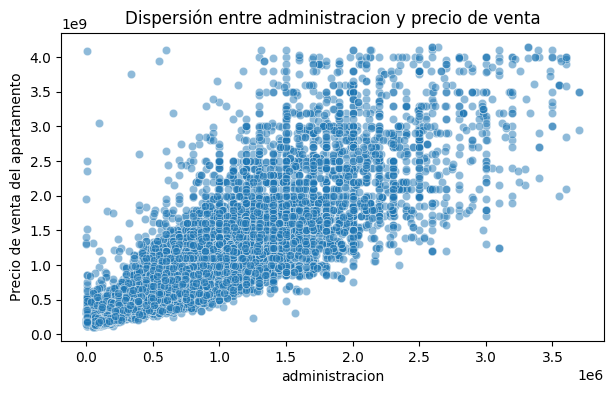

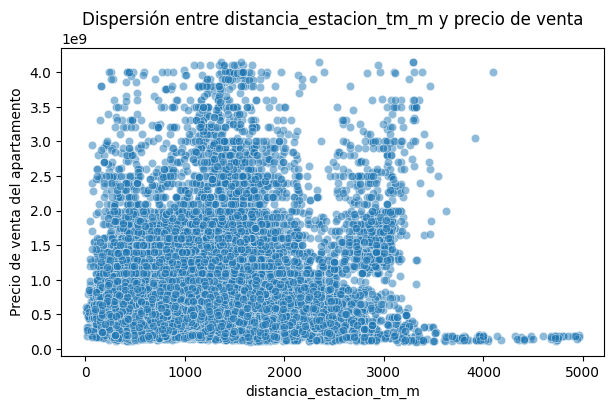

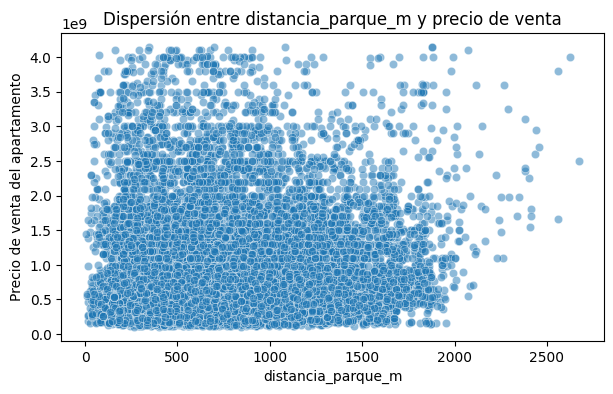

In [19]:
var_analizar = var_num_continuas
for var in var_analizar:
    plt.figure(figsize=(7,4))
    sns.scatterplot(x=var, y=train['precio_venta'], data=train, alpha=0.5)
    plt.title(f'Dispersión entre {var} y precio de venta')
    plt.xlabel(var)
    plt.ylabel('Precio de venta del apartamento')
    plt.show()

Partiendo de este análisis, se seleccionan las variables numéricas continuas precio de administración y área del inmueble. También se tendran en cuenta las variables categóricas hechas dummy y las variables numéricas discretas como número de habitaciones, baños y beneficios

In [20]:
#Se separa cada conjunto de datos train en X y y

X_train = train.drop(columns='precio_venta')
y_train = train['precio_venta']


X_test = test.drop(columns='precio_venta')
y_test = test['precio_venta']

X_val = val.drop(columns='precio_venta')
y_val = val['precio_venta']


#Se definen las columnas de variables categóricas y numéricas
cat_vars = [col for col in X_train.columns 
            if col.startswith('estrato_') 
            or col.startswith('antiguedad_') 
            or col.startswith('localidad_')]
            

num_vars = ['area', 'administracion']

#Variables finales a analizar en los modelos
vars_final = cat_vars + num_vars + val_num_disc

#Los datasets quedan solo con las variables deseadas
X_train = X_train[vars_final]
X_test = X_test[vars_final]
X_val = X_val[vars_final]

#Se realiza el escalamiento de acuerdo con el conjunto de datos X_train
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)


## Punto 2 y 3: Entrenamiento del modelo de Machine Learning y análisis cuantitativo de resultados del modelo

En esta seccion se presenta de manera continua los modelos entrentados y el análisis cuantitativo que corresponde de manera respectiva

### Modelo de regresión lineal

Se comienza por un modelo simple de regresión. Se encuentra un coeficiente de correlación de 0.866 y un error absoluto medio de 187'000.000, el cual parece elevado pero entendiendo el contexto de negocio de apartamentos mayoritariamente de estrato 6, puede representar una mala metrica.

En general este modelo explica un 86% de la varianza, y el promedio de los errores es de 187millones

In [91]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
modelo = LinearRegression()
modelo.fit(X_train_scaled,y_train)
y_pred = modelo.predict(X_test_scaled)
residuos = y_test - y_pred
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R² (coeficiente de determinación): {r2:.3f}')
print(f'MAE (error absoluto medio): {mae:.2f}')
print(f'RMSE (raíz del error cuadrático medio): {rmse:.2f}')

R² (coeficiente de determinación): 0.866
MAE (error absoluto medio): 187000229.94
RMSE (raíz del error cuadrático medio): 283656940.73


In [22]:
#Evaluación del MAPE para concoer comportamiento con registros relativos
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"MAPE: {mape:.2f}%")

MAPE: 24.17%


Con respecto a la dispersión de los puntos predichos contra los puntos reales, se evidencia que los mayores errores corresponden a apartamentos que tienen un mayor valor de venta. De esta manera, se puede llegar a decir que el modelo se comporta especialmente bien para apartamentos de valor de venta menor a 2.000 millones COP, zona donde se encuentra la menor dispersión

Este es un comportamiento que se vera repetido en los siguientes modelos. Los valores de apartamentos mas altos generan errores altos que afectan los valores como el MAE

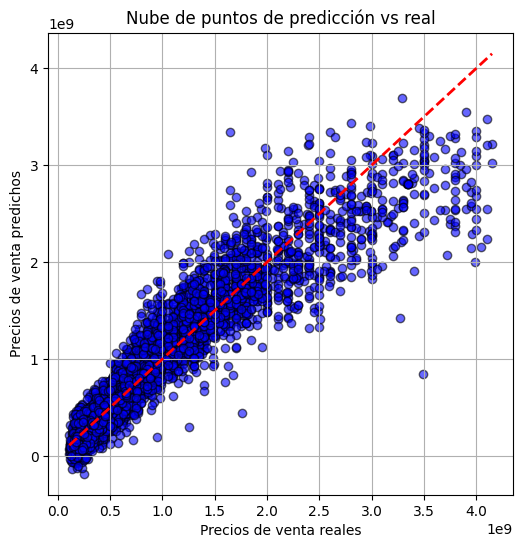

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6, color="blue", edgecolor="k")

# Línea de referencia (predicción perfecta)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)

plt.xlabel("Precios de venta reales")
plt.ylabel("Precios de venta predichos")
plt.title("Nube de puntos de predicción vs real")
plt.grid(True)
plt.show()


Haciendo un análisis de los diagramas de cajas y bigotes, se comprueba lo anteriormente evidenciado: Los valores predichos se mantienen semejantes en gran medida del dataset, teniendo cortes de Q1 y Q3 cercanos, sin embargo, los valores atípicos es donde se presenta mayor diferencia.

               Real      Predicho
27131  1.950000e+09  1.665447e+09
19905  8.830000e+08  1.040483e+09
20558  1.100000e+09  1.187248e+09
22491  6.000000e+08  5.345374e+08
40355  1.760000e+08  1.858828e+08


C:\Users\palsan05\AppData\Local\Temp\ipykernel_56960\105694961.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Tipo', y='precio_venta', data=data_long, palette='Set1')


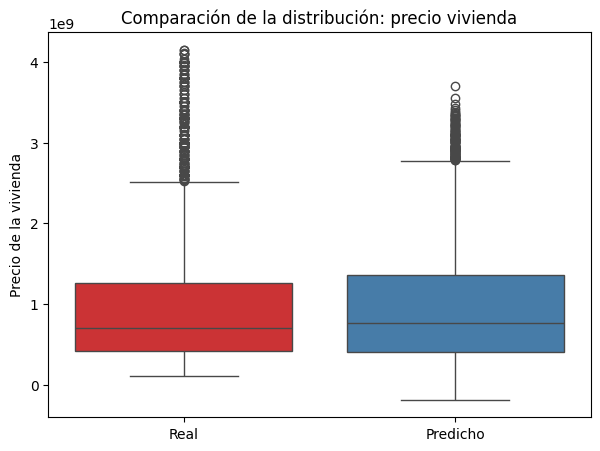

In [24]:
datos_comparacion = pd.DataFrame({
    'Real': y_test,
    'Predicho': y_pred
})
print(datos_comparacion.head())
data_long = pd.melt(datos_comparacion, var_name='Tipo', value_name='precio_venta')

plt.figure(figsize=(7,5))
sns.boxplot(x='Tipo', y='precio_venta', data=data_long, palette='Set1')
plt.title('Comparación de la distribución: precio vivienda')
plt.ylabel('Precio de la vivienda')
plt.xlabel('')
plt.show()

Haciendo más pruebas estadísticas, se encuentra que los residuos se concentran alrededor de 0, mientras que el QQ plot evidencia que la mayor parte de los errores se conecntran en valores de venta elevados

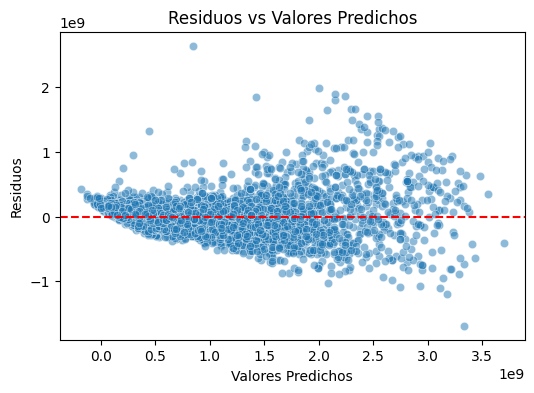

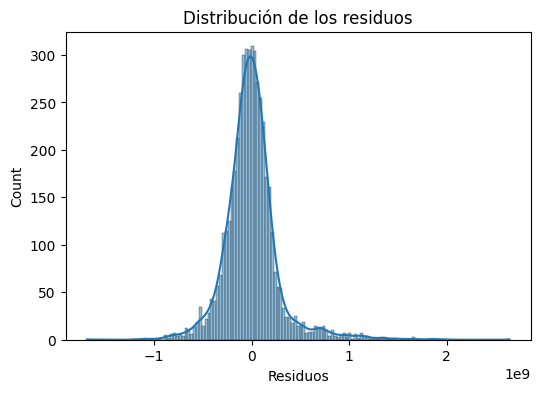

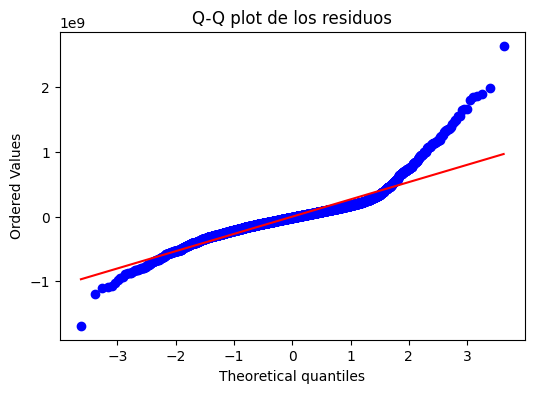

In [25]:
# Análisis gráfico y estadístico de los residuos
import scipy.stats as stats
# Gráfico de residuos vs valores predichos
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuos, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Valores Predichos")
plt.ylabel("Residuos")
plt.title("Residuos vs Valores Predichos")
plt.show()

# Histograma de residuos
plt.figure(figsize=(6,4))
sns.histplot(residuos, kde=True)
plt.xlabel("Residuos")
plt.title("Distribución de los residuos")
plt.show()

# Q-Q plot de los residuos
plt.figure(figsize=(6,4))
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("Q-Q plot de los residuos")
plt.show()


Se realizó un diagrama violín para estudiar la distribución del dataset de test frente al dataset de predicción. Se encuentran comportamientos semejantes en las bases, con diferencias en precios de venta alto

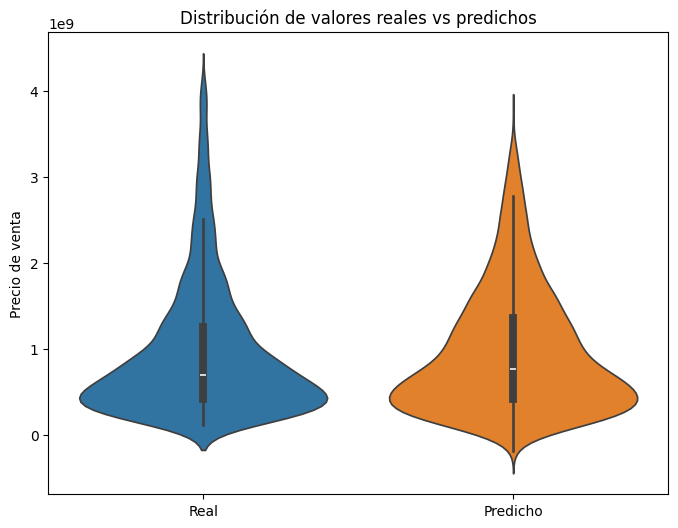

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Crear un DataFrame temporal para graficar
df_plot = pd.DataFrame({
    "Real": y_test,
    "Predicho": y_pred
})

plt.figure(figsize=(8,6))
sns.violinplot(data=df_plot)
plt.title("Distribución de valores reales vs predichos")
plt.ylabel("Precio de venta")
plt.show()


### Modelo polinomial de segundo grado

Como segunda alternativa se realizó el modelo polinomial de segundo grado. En grandes rasgos, se comporta de una manera muy semejante al modelo de regresión lineal. El R2 es de 0.89 y el error absoluto medio es de aproxiamdamente 154.000.000. 

En lineas generales, es ligeramente mejor que el modelo de regresión lineal propuesto anteriormente pues manteniendo las mismas columnas y conjunto de datos, obtiene mejores metricas de evaluacion

In [27]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
modelo_poly = LinearRegression()
modelo_poly.fit(X_train_poly, y_train)
y_pred_poly = modelo_poly.predict(X_test_poly)
residuos_poly = y_test - y_pred_poly
# Métricas
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("=== Regresión Polinomial (grado 2) ===")
print(f"R²: {r2_poly:.3f}")
print(f"MAE: {mae_poly:.2f}")
print(f"RMSE: {rmse_poly:.2f}")

=== Regresión Polinomial (grado 2) ===
R²: 0.892
MAE: 154139642.29
RMSE: 255273580.60


En lineas generales, la predicción se comporta semejante a la regresión lineal, con predicciones acertadas para precios de venta bajos, pero con disperisones según va incrementando.

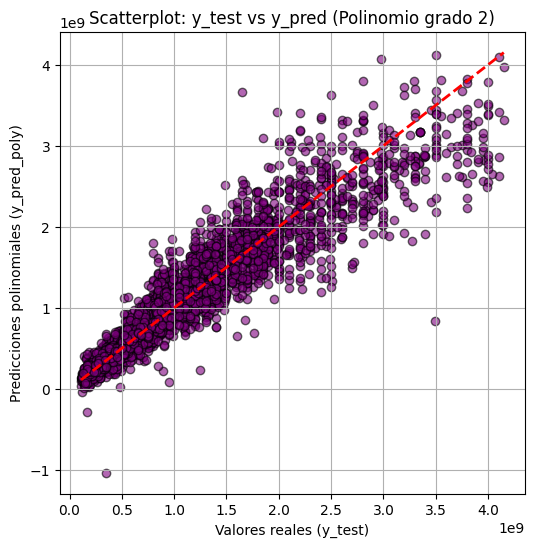

In [28]:
import matplotlib.pyplot as plt

# Supongamos que ya tienes y_test y y_pred_poly definidos
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_poly, alpha=0.6, color='purple', edgecolor='k')

# Línea de referencia (predicción perfecta)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)

plt.xlabel("Valores reales (y_test)")
plt.ylabel("Predicciones polinomiales (y_pred_poly)")
plt.title("Scatterplot: y_test vs y_pred (Polinomio grado 2)")
plt.grid(True)
plt.show()



El valor real frente al valor predicho se mantiene consistente con las distribuciones de precios de venta, con mayor presencia de valores atípicos

               Real      Predicho
27131  1.950000e+09  2.050839e+09
19905  8.830000e+08  8.529032e+08
20558  1.100000e+09  1.124932e+09
22491  6.000000e+08  6.330683e+08
40355  1.760000e+08  1.940131e+08


C:\Users\palsan05\AppData\Local\Temp\ipykernel_56960\229997591.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Tipo', y='precio_venta', data=data_long, palette='Set1')


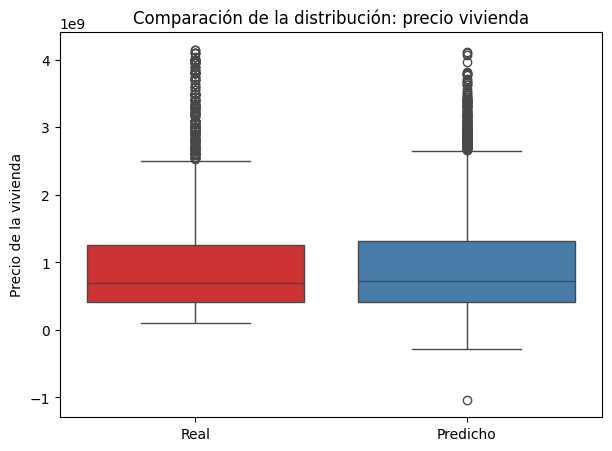

In [29]:
datos_comparacion = pd.DataFrame({
    'Real': y_test,
    'Predicho': y_pred_poly
})
print(datos_comparacion.head())
data_long = pd.melt(datos_comparacion, var_name='Tipo', value_name='precio_venta')

plt.figure(figsize=(7,5))
sns.boxplot(x='Tipo', y='precio_venta', data=data_long, palette='Set1')
plt.title('Comparación de la distribución: precio vivienda')
plt.ylabel('Precio de la vivienda')
plt.xlabel('')
plt.show()

Las gráficas de análisis estadístico como dispersión de error y QQ plot muestra comportamientos semejante a la regresión lineal; Alta concentracion de residuos cerca del 0, y colas que se alejan en los extremos

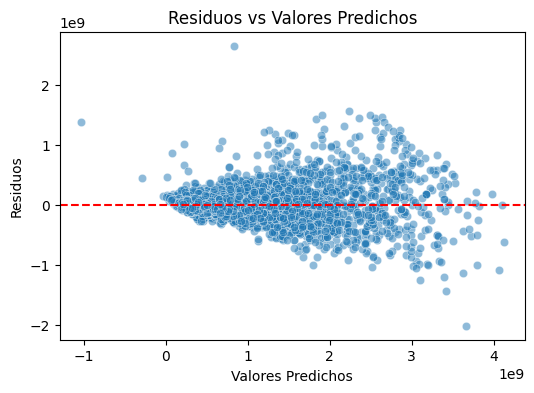

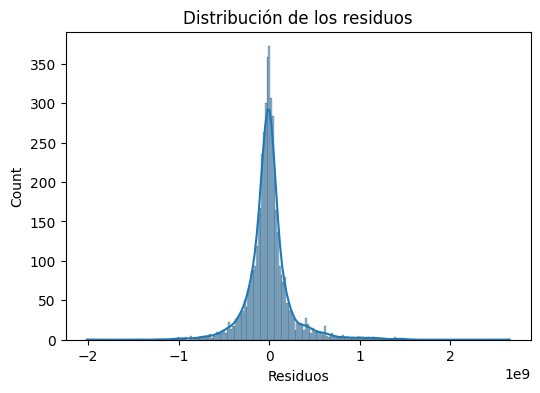

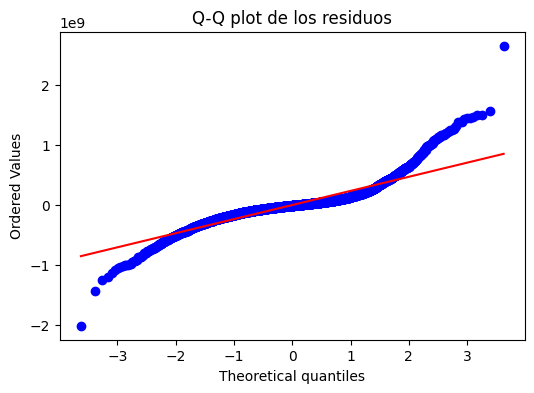

In [30]:
# Análisis gráfico y estadístico de los residuos
import scipy.stats as stats
# Gráfico de residuos vs valores predichos
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred_poly, y=residuos_poly, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Valores Predichos")
plt.ylabel("Residuos")
plt.title("Residuos vs Valores Predichos")
plt.show()

# Histograma de residuos
plt.figure(figsize=(6,4))
sns.histplot(residuos_poly, kde=True)
plt.xlabel("Residuos")
plt.title("Distribución de los residuos")
plt.show()

# Q-Q plot de los residuos
plt.figure(figsize=(6,4))
stats.probplot(residuos_poly, dist="norm", plot=plt)
plt.title("Q-Q plot de los residuos")
plt.show()


### Modelo  random forest de regresión

Finalmente se opta por un modelo de Random Forest Regresion, se encuentrau un R2 de 0.90 y un MAE de aproximadamente 136 Millones COP, los valores más bajos para las distribuciones estudiadas.

Este modelo obtiene los mejores resultados hasta el momento, logrando reducir el MAE y aumentar ligeramente el R2

In [31]:
from sklearn.ensemble import RandomForestRegressor
# Modelo 2: Random Forest
modelo_rf = RandomForestRegressor(random_state=42)
modelo_rf.fit(X_train_scaled, y_train)
y_pred_rf = modelo_rf.predict(X_test_scaled)
residuos_rf = y_test - y_pred_rf

print("Random Forest R²:", r2_score(y_test, y_pred_rf))
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))

Random Forest R²: 0.9046534926764993
Random Forest MAE: 136368465.54668087


El modelo parece ser más consistente para apartamentos con un valor de venta menor a 2000 millones COP, mientras que la dispersión aumenta para apartamentos de mayor valor al mencionado.

Comparado con los modelos anteriores, este modelo de Random Forest es mejor con los apartamentos de menor precio, pero tambien se comporta peor con los apartamentos de mayor precio.

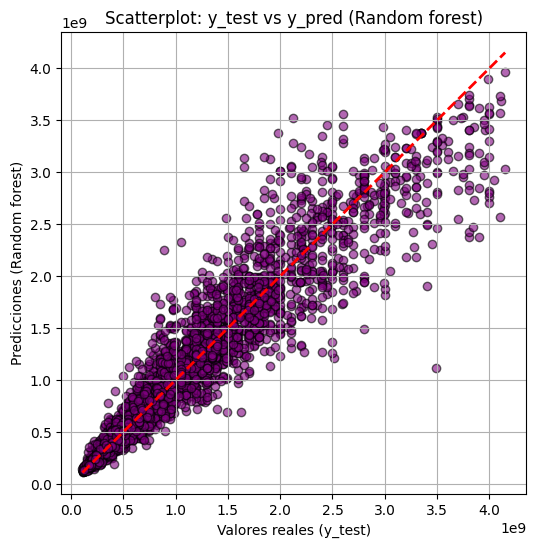

In [92]:
import matplotlib.pyplot as plt

# Supongamos que ya tienes y_test y y_pred_poly definidos
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='purple', edgecolor='k')

# Línea de referencia (predicción perfecta)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)

plt.xlabel("Valores reales (y_test)")
plt.ylabel("Predicciones (Random forest)")
plt.title("Scatterplot: y_test vs y_pred (Random forest)")
plt.grid(True)
plt.show()


En el caso de la gráfica de cajas y bigotes de los valores reales vs valores predichos, se evidencia la distribución de las cajas más semejante evidenciada previamente, garantizando resultados más acertados hasta para el 75% de los datos

               Real      Predicho
27131  1.950000e+09  1.932660e+09
19905  8.830000e+08  9.467987e+08
20558  1.100000e+09  1.054990e+09
22491  6.000000e+08  6.095060e+08
40355  1.760000e+08  1.820227e+08


C:\Users\palsan05\AppData\Local\Temp\ipykernel_56960\2931539488.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Tipo', y='precio_venta', data=data_long, palette='Set1')


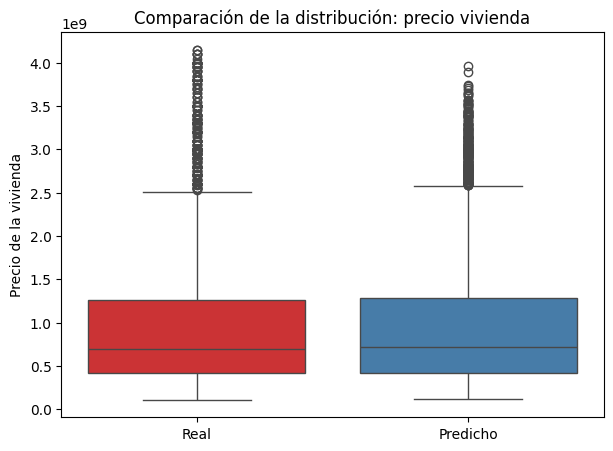

In [33]:
datos_comparacion = pd.DataFrame({
    'Real': y_test,
    'Predicho': y_pred_rf
    
})
print(datos_comparacion.head())
data_long = pd.melt(datos_comparacion, var_name='Tipo', value_name='precio_venta')

plt.figure(figsize=(7,5))
sns.boxplot(x='Tipo', y='precio_venta', data=data_long, palette='Set1')
plt.title('Comparación de la distribución: precio vivienda')
plt.ylabel('Precio de la vivienda')
plt.xlabel('')
plt.show()

En el caso del QQ del modelo de random forest, se encuentra una dispersión de probabilidades en ambos lados de la curbva, diferente a lo evidenciado en als regresiones lineales

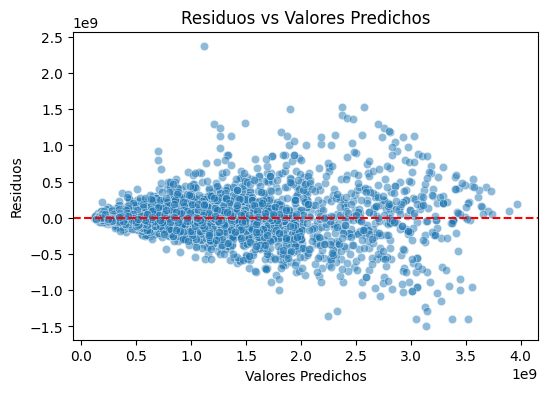

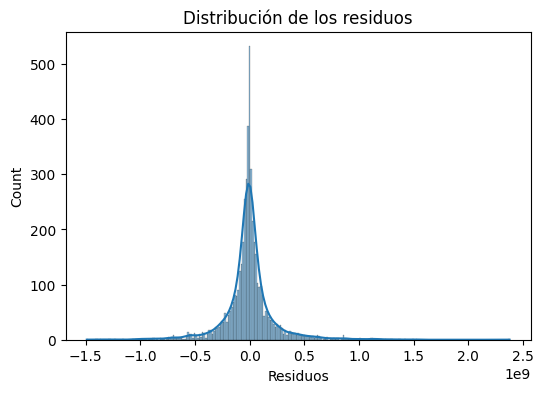

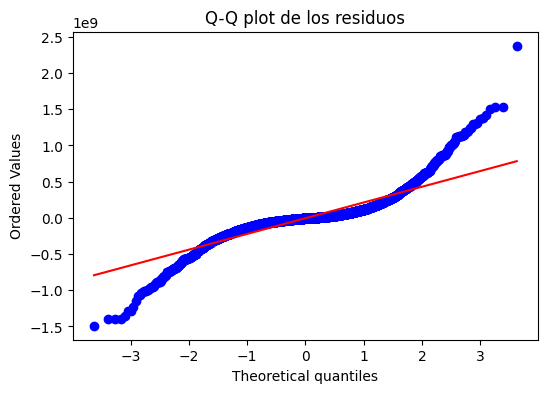

In [34]:
# Análisis gráfico y estadístico de los residuos
import scipy.stats as stats
# Gráfico de residuos vs valores predichos
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred_rf, y=residuos_rf, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Valores Predichos")
plt.ylabel("Residuos")
plt.title("Residuos vs Valores Predichos")
plt.show()

# Histograma de residuos
plt.figure(figsize=(6,4))
sns.histplot(residuos_rf, kde=True)
plt.xlabel("Residuos")
plt.title("Distribución de los residuos")
plt.show()

# Q-Q plot de los residuos
plt.figure(figsize=(6,4))
stats.probplot(residuos_rf, dist="norm", plot=plt)
plt.title("Q-Q plot de los residuos")
plt.show()

### Uso del dataset de validación para el modelo de random forest

In [35]:
# Supongamos que Random Forest fue mejor
y_val_pred = modelo_rf.predict(X_val_scaled)

print("Validation R²:", r2_score(y_val, y_val_pred))
print("Validation MAE:", mean_absolute_error(y_val, y_val_pred))


Validation R²: 0.9039625532615434
Validation MAE: 133228527.21665357


El modelo se muestra consistente frente al dataset de validación, con un MAE de 133 Millones COP. La gráfica de dispersión de puntos demuestra la relación existente.

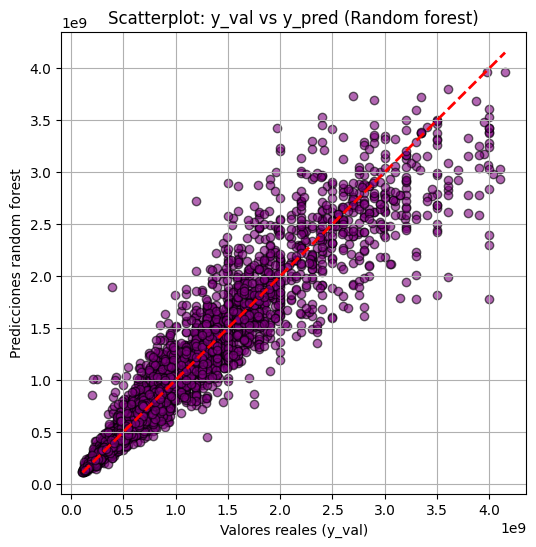

In [36]:
import matplotlib.pyplot as plt

# Supongamos que ya tienes y_test y y_pred_poly definidos
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_val_pred, alpha=0.6, color='purple', edgecolor='k')

# Línea de referencia (predicción perfecta)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)

plt.xlabel("Valores reales (y_val)")
plt.ylabel("Predicciones random forest")
plt.title("Scatterplot: y_val vs y_pred (Random forest)")
plt.grid(True)
plt.show()


## Punto 4: Interpretabilidad del modelo

Se va a realizar la interpretabilidad de  modelo a través de lime y de valores shapley

### lime

In [37]:
from lime.lime_tabular import LimeTabularExplainer

# Crear el explainer con tus datos de entrenamiento
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=['precio_venta'],
    mode='regression'
)
#Generamos los datos desescalados para poder mapearlos
x_original = scaler.inverse_transform(X_test_scaled)[0]
x_original


array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  1.00000000e+00,  1.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        1.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        3.46944695e-18,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        2.16840434e-19,  0.00000000e+00,  0.00000000e+00, -3.46944695e-18,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.62000000e+02,
        1.04000000e+06,  3.00000000e+00,  5.00000000e+00,  2.00000000e+00,
        1.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00])

In [38]:
# Ejemplo: primera fila del test
i = 500
exp = explainer.explain_instance(
    data_row=X_test.iloc[i].values,
    predict_fn=modelo_rf.predict  # o el modelo que quieras interpretar
)

In [39]:
idx = 520
instance = X_test_scaled[idx]
print("Predicción Random Forest:", modelo_rf.predict([instance]))

exp_rf = explainer.explain_instance(instance, modelo_rf.predict, num_features=6, num_samples=100)
print("Local fidelity (R²):", exp_rf.score)

exp_rf.domain_mapper.feature_values = [
    val for  val in x_original
]

exp_rf.as_list()



Predicción Random Forest: [3.32821403e+08]
Local fidelity (R²): 0.7432311725407181


[('antiguedad_MAS DE 20 ANOS > 1.00', -1478542184.0346997),
 ('beneficios <= 1.00', -161761734.11334518),
 ('localidad_CHAPINERO <= 0.00', -146739200.521824),
 ('antiguedad_ENTRE 10 Y 20 ANOS <= 0.00', -106265265.2358084),
 ('is_cerca_parque <= 0.00', 42174048.73262671),
 ('is_cerca_estacion_tm <= 0.00', 37559618.15216873)]

En el caso de los valores lime, se encuentra que para el modelo de regresión realizado la antiguedad, el área y no ser estrato 4 restó valor. La no-cercanía a parques o estaciónes de TransMilenio, siendo de Usaquén, sumó valor

In [40]:
idx = 799
instance = X_test_scaled[idx]
print("Predicción Random Forest:", modelo_rf.predict([instance]))

exp_rf = explainer.explain_instance(instance, modelo_rf.predict, num_features=6, num_samples=100)
print("Local fidelity (R²):", exp_rf.score)

exp_rf.domain_mapper.feature_values = [
    val for  val in x_original
]

exp_rf.as_list()


Predicción Random Forest: [1.17291e+09]
Local fidelity (R²): 0.7245077867800249


[('estrato_6.0 > 1.00', -1094128265.3046117),
 ('beneficios <= 1.00', -134865161.4464277),
 ('antiguedad_ENTRE 0 Y 5 ANOS <= 0.00', -84201522.42686169),
 ('localidad_CHAPINERO <= 0.00', -72904378.11763912),
 ('antiguedad_MAS DE 20 ANOS <= 0.00', 36347717.64862111),
 ('is_cerca_parque <= 0.00', 25360998.23492887)]

En el caso del inmueble 799, ser estrato 6, sin beneficios, sin tener una antiguedad de entre 0 y 5 años, restó valor. agregó valor el no estar cefrca a estaciones de TM

In [41]:
idx = 1112
instance = X_test_scaled[idx]
print("Predicción Random Forest:", modelo_rf.predict([instance]))

exp_rf = explainer.explain_instance(instance, modelo_rf.predict, num_features=6, num_samples=100)
print("Local fidelity (R²):", exp_rf.score)

exp_rf.domain_mapper.feature_values = [
    val for  val in x_original
]

exp_rf.as_list()

Predicción Random Forest: [4.74915e+08]


C:\Users\palsan05\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.62056e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\palsan05\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=6.66189e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\palsan05\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=4.77019e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Local fidelity (R²): 0.7330271930890001


C:\Users\palsan05\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=4.67746e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\palsan05\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=4.21421e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


[('antiguedad_ENTRE 10 Y 20 ANOS > 1.00', -1454261029.9525883),
 ('localidad_CHAPINERO <= 0.00', -141417641.66768602),
 ('beneficios <= 1.00', -98511945.23756184),
 ('localidad_SUBA <= 0.00', 51001321.54753863),
 ('antiguedad_MAS DE 20 ANOS <= 0.00', 39497323.510087475),
 ('is_cerca_parque <= 0.00', 28629003.428885814)]

En el inmueble 1222, restó valor estar entre 10 y 20 años, y tener pocas habitaciones. Sumó valor no estar en Los Mártires o Suba

In [42]:
idx = 4240
instance = X_test_scaled[idx]
print("Predicción Random Forest:", modelo_rf.predict([instance]))

exp_rf = explainer.explain_instance(instance, modelo_rf.predict, num_features=6, num_samples=100)
print("Local fidelity (R²):", exp_rf.score)

exp_rf.domain_mapper.feature_values = [
    val for  val in x_original
]

exp_rf.as_list()

Predicción Random Forest: [5.8484055e+08]


C:\Users\palsan05\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.81143e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\palsan05\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.81143e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\palsan05\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=3.2195e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\palsan05\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=3.2195e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_

Local fidelity (R²): 0.738739252622002


C:\Users\palsan05\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.33525e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\palsan05\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.33525e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\palsan05\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.08141e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\palsan05\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.08141e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrit

[('antiguedad_MAS DE 20 ANOS > 1.00', -1314905158.8916402),
 ('is_cerca_estacion_tm > 0.00', -141867104.6377954),
 ('localidad_CHAPINERO <= 0.00', -121124338.80673625),
 ('beneficios <= 1.00', -107769628.8960108),
 ('antiguedad_ENTRE 10 Y 20 ANOS <= 0.00', -87741781.94297276),
 ('banos <= 2.00', -7628434.587027919)]

En el caso del inmueble 4240, restó valor tener una antiguedad de más de 20 años, no tener beneficios y no estar en Chapinero

In [43]:
idx = 1000
instance = X_test_scaled[idx]
print("Predicción Random Forest:", modelo_rf.predict([instance]))

exp_rf = explainer.explain_instance(instance, modelo_rf.predict, num_features=6, num_samples=100)
print("Local fidelity (R²):", exp_rf.score)

exp_rf.domain_mapper.feature_values = [
    val for  val in x_original
]

exp_rf.as_list()

Predicción Random Forest: [4.81696376e+08]
Local fidelity (R²): 0.7357243767504467


[('antiguedad_MAS DE 20 ANOS > 1.00', -1401992806.145098),
 ('habitaciones <= 2.00', -105533569.18418261),
 ('beneficios <= 1.00', -89731463.06235589),
 ('localidad_CHAPINERO <= 0.00', -83096442.61127977),
 ('antiguedad_ENTRE 10 Y 20 ANOS <= 0.00', -74710725.34664325),
 ('is_cerca_estacion_tm <= 0.00', 53041924.715425394)]

En el inmueble 100, restó en el valor no tener beneficios, ni estar en la localidad de suba, y tener más de 20 años

Los ejemplos vistos en Lime representan escenario reales que tienen sentido y confirman las creencias previas sobre el comportamiento del mercado inmobiliario 

### Shaply

Estudiando el diagrama de enjambre de valores shaply, se identifica que el área y la adminsitración impacta de manera directa el valor del inmueble, al igual que el hecho de estar en la localidad de Chapinero, el numerod e baños y que tenga una antiguedad de 0 a 5 años.

en contra parte, la antigudad de más de 20 añosjuega un rol importante para decrecer el valor de los inmuebles. el uso de beneficios no parece influenciar en gran medida el valor de los inmuebles.

100%|===================| 4822/4834 [04:28<00:00]        

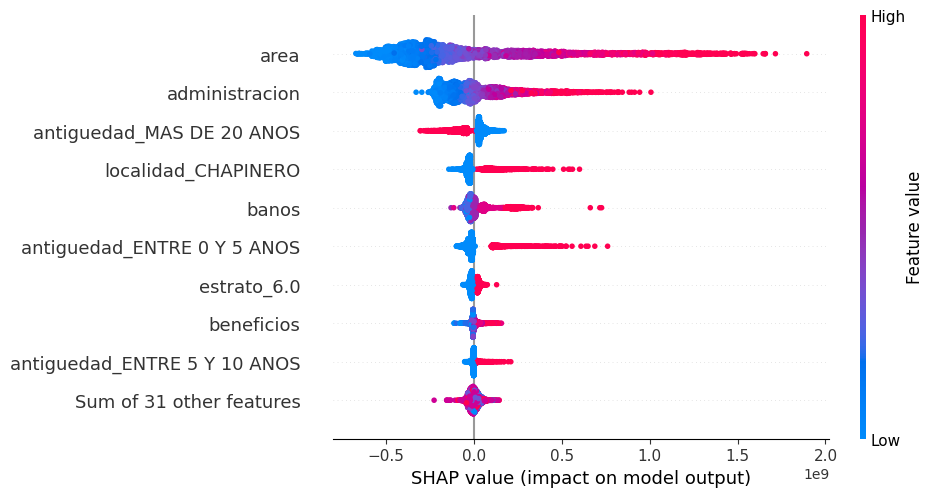

IndexError: index 40 is out of bounds for axis 0 with size 40

In [44]:

import shap
shap.initjs()

# Explainer para regresión
explainer_rf = shap.TreeExplainer(modelo_rf, X_train_scaled, feature_names=X_train.columns)

# Calcular valores SHAP
shap_values_rf = explainer_rf(X_test_scaled, check_additivity=False)

# Restaurar datos originales si quieres
shap_values_rf.data = scaler.inverse_transform(X_test_scaled)

# Beeswarm plot (impacto global de las variables)
shap.plots.beeswarm(shap_values_rf)

# Force plot (explicación local de una instancia)
# Ejemplo: primera observación
shap.force_plot(
    explainer_rf.expected_value,
    shap_values_rf.values[0,:],
    X_test.iloc[0,:],
    feature_names=X.columns
)


Valor de la etiqueta en el dataset: 950000000.0
Valor predecido por el modelo: 1001720000.0


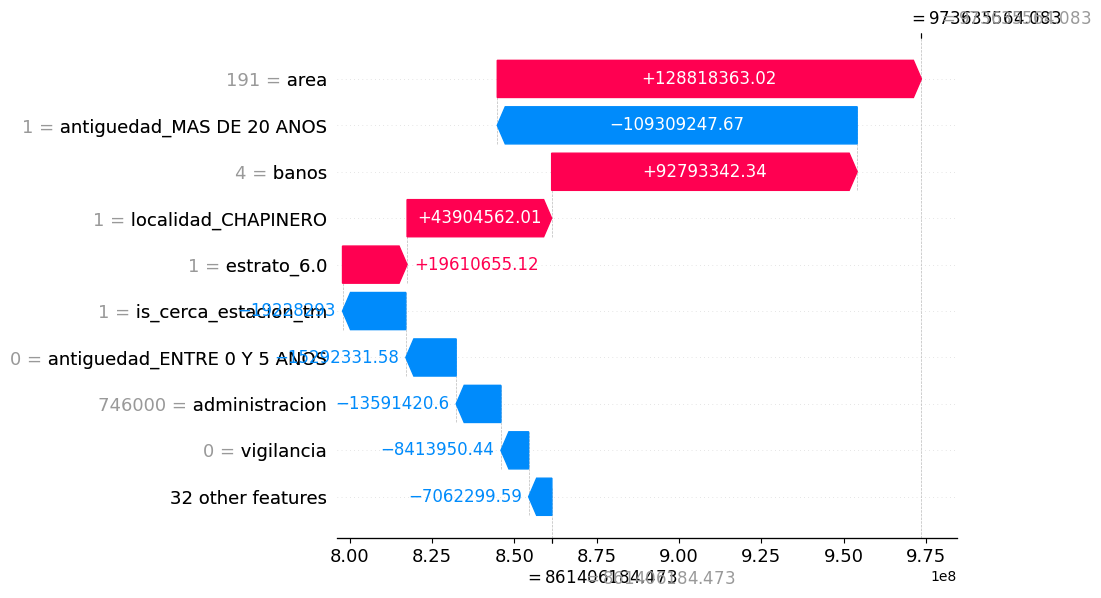

In [ ]:
sample_index = 160    # seleccionamos la muetra
print("Valor de la etiqueta en el dataset:" ,y_test.to_numpy()[sample_index])
print("Valor predecido por el modelo:",y_pred_rf[sample_index])


shap.plots.waterfall(shap_values_rf[sample_index])

Analizando el diagrama de cascada de los valores shapley, se enceuntra que los elementos que tienden a incrementar en mayor medida el valor del inmueble son el área del inmueble, el número de baños y el estrato socioecónomico. En contra partee, una antiguedad de más de 20 años, que esté cerca a estaciónd e transmilenio, que no tenga vigilancia, que no sea nuevo, y que la administarción sea elevada, hace que el valor de venta baje.

**Conclusiones:**

En general la interpretacion nos da confirmacion que concuerda con ideas previas; 
- El area de los apartamentos impacta positivamente el valor de los mismos (El sector inmobiliario suele hablar de precio por M2)
- La antiguedad de los apartamentos y su estado son relevantes tambien.
- Los estratos estan altamente relacionados y suelen ser variables que aumentan o disminuyen el valor de los apartamentos
- Otras caracteristicas importantes como vigilancia, cercania a puntos de interes, y otros suelen ser positivos como extras o adicionales. 

## Punto 5: Generacion de Valor

### a. Costos asociados:
El principal costo asociado descrito es el costo de los peritos que realizan las evaluaciones de los peritos.

Se define que el proceso de compra requiere 6 horas de trabajo de un perito, y que cada hora de trabajo del perito tiene un valor de 9.500 COP

In [50]:
costo_actual=  6*9500 
costo_actual_mensual = costo_actual * 500
print("El costo actual de proceso de compra para un apartamento es de :", costo_actual)
print("El costo actual mensual es de :", costo_actual_mensual)

El costo actual de proceso de compra para un apartamento es de : 57000
El costo actual mensual es de : 28500000


Actualmente, sin el apoyo de Modelos de ML. El proceso de compra de un apartamento implica 57.000 COP. Manteniendo los 500apartamentos mensuales descritos se tiene un costo de 28'500.00 COP


## b. Ahorro del tiempo teorico: 

Se establece que con el apoyo de un modelo de ML, el tiempo de trabajo del perito se reduciria a una hora.

In [52]:
costo_nuevo =  1*9500
ahorro =  costo_actual - costo_nuevo
ahorro_mensual = ahorro * 500
print('El costo nuevo usando un modelo de ML para el proceso de compra de un apartamento es de: ', costo_nuevo)
print('Existe un ahorro bruto en cada apartamento de :',  ahorro)
print('El ahorro teorico mensual seria de: ', ahorro_mensual)

El costo nuevo usando un modelo de ML para el proceso de compra de un apartamento es de:  9500
Existe un ahorro bruto en cada apartamento de : 47500
El ahorro teorico mensual seria de:  23750000


El ahorro teorico de cada proceso de compra del apartamento es de: 47.500 COP, para un total mensual de 23'750.000 COP

## c. Costo asociado a errores
Segun los datos historicos, cada error de estimacion por debajo de los 20millones COP implica que el cliente solicite un avaluo presencial. Nuevamente el costo actual de 57.000, esto corresponde al Costo Actual y no constituye un costo adicional

**Supuesto:**  Se asume que el flujo es el siguiente:

- El modelo realiza una estimacion

- El perito hace su trabajo de 1hora (contacto al cliente, validacion, etc)

- Si hay una subestimacion superior a 20millones, el cliente solicita un avalua presencial. Lo cual consumiria 6h de trabajo del perito.

Se entiende que el perito realiza 6horas de trabajo, y que cada subestimacion tendria un costo adicional de la primera hora de trabajo perdida.( Se asume que esta primera hora de trabajo realiza tareas diferentes que no contribuyen al proceso de compra) 

En conclusion: Cada error asociado a la subestimacion requiere 7 horas de trabajo:

Como el costo actual es de 6 horas de trabajo. Se define que, el costo asociado a cada error del modelo es de 1hora de trabajo = 9,500 COP


In [78]:
costo_error = 9500

#Calculo de ratio de subestimaciones. Se usa los residuos del Modelo de RandomForestRegressor pues este obtuvo las mejores metricas
count_under_20m = sum(residuos_rf < -20000000)
print(f"Número de residuos menores a 20 millones: {count_under_20m}")

ratio_subestimacion = count_under_20m / len(residuos_rf)
print("El ratio de apartamentos con uns subestimacion inferior a 20millones de pesos es de",ratio_subestimacion)

costo_error_mensual = costo_error * (500*ratio_subestimacion)

print("El costo de los errores asociado a errores del modelo es de: ", costo_error_mensual)



Número de residuos menores a 20 millones: 2073
El ratio de apartamentos con uns subestimacion inferior a 20millones de pesos es de 0.42883740173769136
El costo de los errores asociado a errores del modelo es de:  2036977.6582540341


Se espera que los costos asociados a errores del modelo sea de : 2'036.977 COP

## d. Ahorro real por estimacion acertada.

In [68]:
ratio_aciertos = 1 - ratio_subestimacion

ahorro_mensual_real = ahorro_mensual * ratio_aciertos
print("El ratio de estimacion que seran aceptadas es de: ",ratio_aciertos)
print("El ahorro mensual sin gastos de costos de errores: ", ahorro_mensual_real)
ahorro_mensual_real_gastos = ahorro_mensual_real - costo_error_mensual
print("El ahorro mensual incluyendo gastos de costos de errores: ", ahorro_mensual_real_gastos)


El ratio de estimacion que seran aceptadas es de:  0.5711625982623086
El ahorro mensual sin gastos de costos de errores:  13565111.70872983
El ahorro mensual incluyendo gastos de costos de errores:  11528134.050475795


Se concluye que hay un ahorro mensual real de 11'528.134 COP

## e. ROI y costos de desarrollo:

**Supuesto** Para los costos de desarrollo se toma los datos desde la experiencia propia del grupo de trabajo. Haciendo una aproximacion de horas invertidas en el desarrollo del presente taller, y aproximaciones de los salarios de los estudiantes que lo desarrollan, se define un costo de desarrollo de 1'500.000 COP


In [74]:
costo_desarrollo = 1500000
#ROI simple
ganancia_prediccion_ajustada = (ahorro - (1 - ratio_aciertos) * costo_error)
print(ganancia_prediccion_ajustada)

43426.044683491935


In [76]:
returns = ahorro_mensual_real_gastos
investments= costo_desarrollo

#ROI SIMPLE
roi = returns/investments
print(roi)

#Break even
even =costo_desarrollo / ahorro_mensual_real_gastos
print(even)

7.685422700317196
0.13011646060258045


Este ROI simple nos indicaria que el retorno de la inversion es 7.86 veces mayor que la inversion. 

El punto de break even, considerando un costo de desarrollo de 1'500.000 y un ahorro mensual de 11'528.134  es de 0.13, Lo que corresponderia que la inversion se recupera en menos de un mes.


Finalmente se debe considerar tambien que  el ahorro o la reduccion en horas de trabajo de los peritos podria habilitar la posibilidad de incrementar la base de clientes o el portafolio de servicios de la empresa. 

El modelo no solo es rentable y de pronta recuperacion de la inversion, si no que tambien permitiria tener mas de 500 clientes/apartamentos mensuales, aumentando aun mas su valor 
